In [1]:
import torch
import numpy as np
import sys
sys.path.append('../../')
import tt_utils
from src.ttts import TTTS

from fcn_plotting_utils import plot_surf, plot_contour, plot_surface_3D_interactive_2
%load_ext autoreload
%matplotlib notebook
np.set_printoptions(precision=3)
%autoreload 2

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
#Himmelbalue2D
from test_fcns import mix_func_2D
L=5
n = 2 # Dimension of the domain
a=11; b=7;
pdf, cost = mix_func_2D(alpha=1.0)
print("This has multiple global optima")
z_max = 2000 # for plotting
log_norm = True # for plotting

This has multiple global optima


##### Discretize the domain

In [6]:
# Define the domain of the function
d = 1000 # discretization of each axis
domain = [torch.linspace(0, 10,11).to(device)]+ [torch.linspace(-L,L,d).to(device)]

In [7]:
ttts = TTTS(func = pdf, domain = domain, value_k=5, visit_k=5, max_tt=2, 
            warm_start=True, verbose=False, cross_max_iter=2)
sol = ttts.iterate(max_iters = 10, param_C=3) # K x n


cross device is cuda
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
Cross-approximation over a 2D domain containing 11000 grid points:
iter: 0 | eps: 7.451e-01 | time:   0.1072 | largest rank:   1
iter: 1 | eps: 5.931e-01 | time:   0.1524 | largest rank:   2 <- max_iter was reached: 2
Did 3066 function evaluations, which took 0.01426s (2.15e+05 evals/s)

mcts-iters: 1, top-k values: [0.7347185043382569, 0.7286362604076565, 0.7242341203288062, 0.721282137884304, 0.7140237037810349]
mcts-iters: 2, top-k values: [0.7347185043382569, 0.7286362604076565, 0.7242341203288062, 0.721282137884304, 0.7140237037810349]
mcts-iters: 3, top-k values: [0.7347185043382569, 0.7286362604076565, 0.7242341203288062, 0.721282137884304, 0.7140237037810349]
mcts-iters: 4, top-k values: [0.7347185043382569, 0.7286362604076565, 0.7242341203288062, 0

In [10]:
ttts_top_k_estimate = sol
ttts_best_estimate = ttts_top_k_estimate[:1]

### TTGO

In [11]:
# Find the tt-model correspondin to the pdf
tt_model = tt_utils.cross_approximate(fcn=pdf,  domain=domain, 
                        rmax=2, nswp=2, eps=1e-3, verbose=True, 
                        kickrank=10, device=device)

cross device is cuda
Functions that require cross-approximation can be accelerated with the optional maxvolpy package, which can be installed by 'pip install maxvolpy'. More info is available at https://bitbucket.org/muxas/maxvolpy.
Cross-approximation over a 2D domain containing 11000 grid points:
iter: 0 

| eps: 8.709e-01 | time:   0.0312 | largest rank:   1
iter: 1 | eps: 7.301e-01 | time:   0.1579 | largest rank:   2 <- max_iter was reached: 2
Did 3066 function evaluations, which took 0.01051s (2.916e+05 evals/s)



In [12]:
tt_model

2D TT tensor:

 11 1000
  |   |
 (0) (1)
 / \ / \
1   2   1

##### Find the TT-Model

In [14]:
ttgo_top_k_estimate = tt_utils.deterministic_top_k(tt_model.cores, domain=domain, n_samples=5, device=device)[0]
print("Samples: ", ttgo_top_k_estimate)

ttgo_best_estimate = ttgo_top_k_estimate[:1]

Samples:  tensor([[3.0000, 1.5766],
        [3.0000, 1.5666],
        [3.0000, 1.5566],
        [3.0000, 1.5465],
        [3.0000, 1.5365]], device='cuda:0')


In [15]:
print("Cost at estimated optima: ", cost(ttgo_best_estimate))
print("Cost at top-k proposals: ", cost(ttgo_top_k_estimate))
print("PDF at estimated optima: ", pdf(ttgo_top_k_estimate))

Cost at estimated optima:  tensor([0.4160], device='cuda:0')
Cost at top-k proposals:  tensor([0.4160, 0.4269, 0.4378, 0.4487, 0.4596], device='cuda:0')
PDF at estimated optima:  tensor([0.6597, 0.6525, 0.6454, 0.6385, 0.6316], device='cuda:0')


Fine tune the TTGO estimate using gradient-based optimization

### Visualize  Samples from TT Model

In [16]:
def cost_plot(x):
    x = torch.from_numpy(x).to(device)
    out =  cost(x).cpu()
    if not (type(out) is np.ndarray):
        out = out.numpy()
    return out
def pdf_plot(x):
    x = torch.from_numpy(x).to(device)
    out =  pdf(x).cpu()
    if not (type(out) is np.ndarray):
        out = out.numpy()
    return out

def get_tt_value(x):
    from tt_utils import get_value
    x = torch.from_numpy(x).to(device)
    n_discretization = torch.tensor([len(dom) for dom in domain]).to(device)
    out = get_value(tt_model, x, domain, n_discretization, device=device)
    out = torch.log(out)*-1
    if not (type(out) is np.ndarray):
        out = out.cpu().numpy()
        
    return out

In [17]:
# # save data
# torch.save({'sol': sol, 'ttgo_best_estimate': ttgo_best_estimate, 'ttts_best_estimate': ttts_best_estimate, 
#             'tt_model': tt_model
# }, 'mix_function_result.pth')

#load data
data = torch.load('mix_function_result.pth', weights_only=False)
sol = data['sol']
ttgo_best_estimate = data['ttgo_best_estimate']
ttts_best_estimate = data['ttts_best_estimate']
tt_model = data['tt_model']

In [18]:
#Himmelbalue2D
from test_fcns import mix_func_2D
L=5
n = 2 # Dimension of the domain
a=11; b=7;
pdf, cost = mix_func_2D(alpha=1.0)
print("This has multiple global optima")
z_max = 2000 # for plotting
log_norm = True # for plotting

This has multiple global optima


In [19]:
ttgo_best_estimate

tensor([[3.0000, 1.5766]], device='cuda:0')

In [20]:
x = np.linspace(0, 10,11)
y = np.linspace(-5,5,d)
# plt = plot_contour(x,y,cost_plot,data=ttgo_top_k_estimate.cpu(), contour_scale=100, figsize=5,log_norm=log_norm)
ground_truth = np.array([0, -1.036])[None, :]
fig = plot_surface_3D_interactive_2(x,y,cost_plot, 
                                  ttgo_best_estimate.cpu().numpy(), ttts_best_estimate.cpu().numpy(), ground_truth)



# plt.plot(ttgo_best_estimate[:,0].cpu(),ttgo_best_estimate[:,1].cpu(),'*b',markersize=10)
# plt.plot(ttts_best_estimate[:,0].cpu(),ttts_best_estimate[:,1].cpu(),'*r',markersize=10)
# plt.title("Cost")

#plt.title(r"Himmelblau: $z=(x^2+y-{})^2+(x+y^2-{})^2$".format(a,b))
#plt.title(r"Rosenbrock: $z=(x-1)^2+100 (y-x^2)^2$".format(11,7))

# plt.savefig('rosenbrock2D_a_99.png',pad_inches=0.01, dpi=300)
# plt.savefig('Himmelblau2D_99.png',pad_inches=0.01, dpi=300)
# plt.savefig('Sine2D_a_0.png',pad_inches=0.01, dpi=300)

min Z: 0.3082678404225537 max Z: 11.576111011909823


Z range: 0.3082678404225537 11.576111011909823


<IPython.core.display.Javascript object>

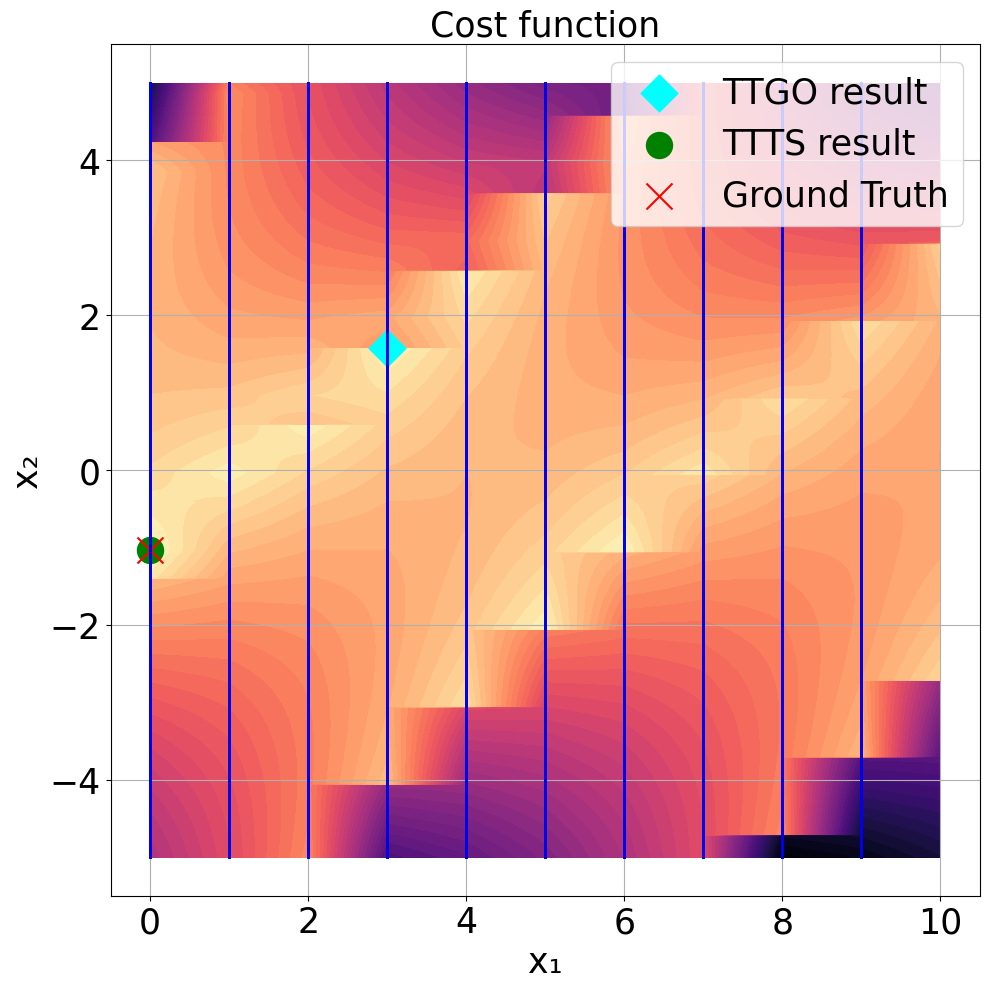

In [21]:
from fcn_plotting_utils import plot_surface_2D

plot_surface_2D(x,y,cost_plot, ttgo_best_estimate.cpu().numpy(), ttts_best_estimate.cpu().numpy(), ground_truth, name='Cost function')


Z range: 0.41597846292924506 10.32643970837552


<IPython.core.display.Javascript object>

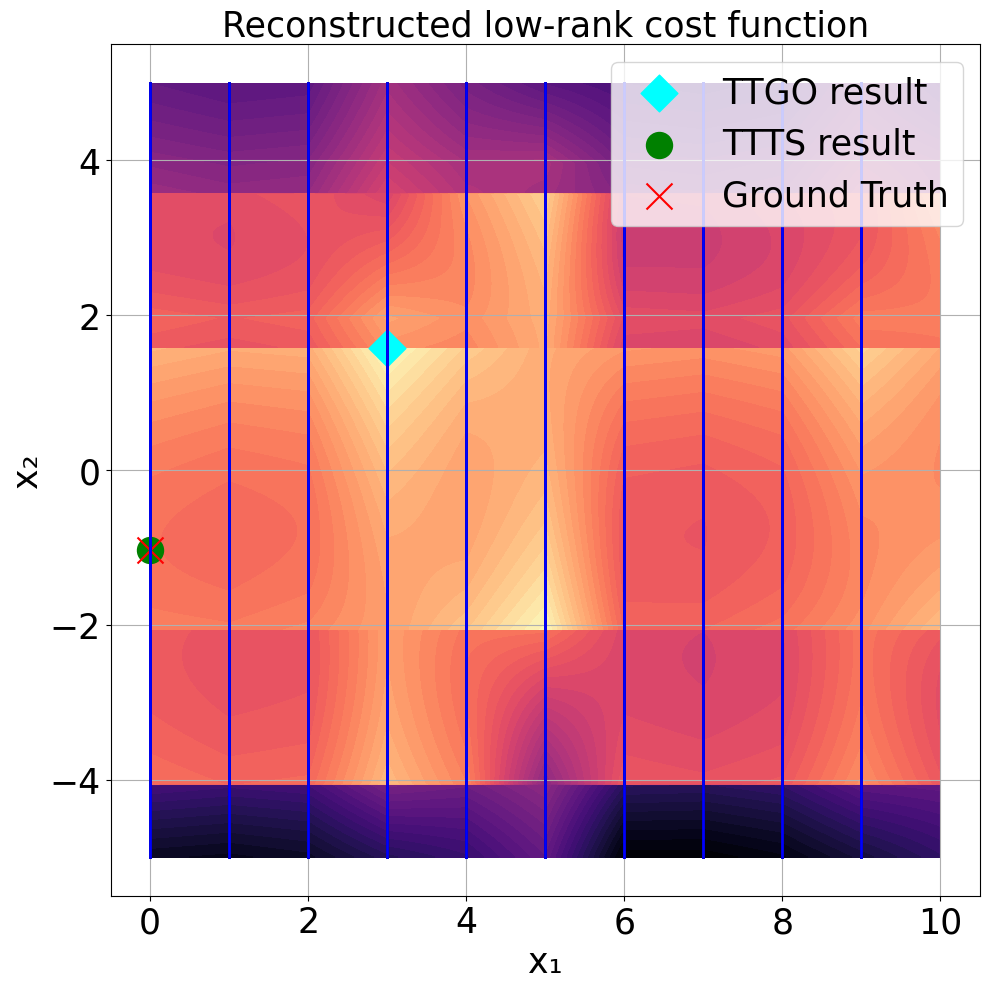

In [22]:
plot_surface_2D(x,y,get_tt_value, ttgo_best_estimate.cpu().numpy(), ttts_best_estimate.cpu().numpy(), ground_truth, name="Reconstructed low-rank cost function")